### Red Flag! : Spotting Potential Illegal Fishing Activity Using AIS Outage Data 

A data story by Cora McKean 

#### Introduction & Context 

The ocean is a hard place to govern, and enforcing fishing regulations can be challenging. Each year, an estimated 11-26 million metric tons of fish are caught illegally or go unreported. 1 in every 5 wild-caught fish that enters global markets has been caught illegally (Global Fishing Watch, 2026). Illegal, unreported, and unregulated fishing (IUU) has a dramatic impact on the economy, food security, and human rights.


The legality surrounding a nation's control of open waters can be precarious. A country's Exclusive Economic Zone (EEZ) extends 200 nautical miles from its coast. Coastal nations govern the portion of the ocean within their EEZ and have sole rights to the resources. Outside of the 200 nm EEZ, international waters called the 'high seas' belong to no singular nation. A large portion of IUU occurs when foreign or otherwise unauthorized vessels enter a nation's EEZ without permission (Welch, et al., 2022).


Vessel tracking data from the Automatic Identification System (AIS) can be used to monitor commercial fishing. However, AIS is not universally mandated and can be disabled for a number of reasons, both legitimate and illegitimate. For example, an AIS signal may be lost due to an equipment malfunction or a satellite dead zone. Additionally, some vessels are exempt from AIS regulations to protect confidential fishing locations or protect themselves from piracy. On the other hand, disabling AIS devices is a strategy used to conceal illegal activity at sea, such as illegal fishing in EEZs or unauthorized transshipments (Welch, et al., 2022). Transshipments refer to the at-sea transfer of fish, personnel, and supplies between fishing vessels and refrigerated cargo vessels. Transshipments can be used to launder illegally caught seafood and dramatically increase the length of time that fishing vessels can remain at sea (NOAA, 2022). In addition to supporting illegal and unregulated fishing practices, transshipments have been linked to numerous human rights issues (Urbina, 2023). 


While disabling AIS does not necessarily signal illegal activity, it definitely raises red flags. This analysis is written for fisheries managers, policy staff, and informed general readers to increase the understanding that a large number of AIS disabling events are not happening at random. Examining AIS outage data with illegal, unreported, and unregulated fishing in mind reveals patterns that may prove useful for future governance and reporting. Improving the ability to identify whether a vessel is participating in illegal fishing and predicting the parts of the world's oceans that are most at risk is critical to protecting the world's fisheries. Examining AIS disabling event data is one of the first steps in identifying patterns that warrant further investigation.


#### Explanation of Tools & Construction 
This dataset was obtained from Global Fishing Watch and is publicly available. (https://globalfishingwatch.org/data-download/datasets/public-welch-et-al-disabling-events%3Av20221102)

As stated on the Global Fishing Watch website, "This dataset includes data on suspected AIS disabling events by commercial fishing vessels between 2017-2019. AIS disabling events are restricted to waters greater than 50 nautical miles from shore with sufficient satellite AIS reception."

This dataset contains 55,368 events from 5,269 unique commercial fishing vessels flying more than 100 flags. Each record gives the position and timestamp where a vessel's AIS transponder stopped broadcasting, the position where it resumed, the gap duration, the vessel's flag, inferred gear type, and distance from shore.

In [3]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

df=pd.read_csv('ais_disabling_events.csv')

In [4]:
df.head()

,gap_id,mmsi,vessel_class,flag,vessel_length_m,vessel_tonnage_gt,gap_start_timestamp,gap_start_lat,gap_start_lon,gap_start_distance_from_shore_m,gap_end_timestamp,gap_end_lat,gap_end_lon,gap_end_distance_from_shore_m,gap_hours
0,40072d9edfca0cfd28872cbf9e382e0c,111112726,other,NaN,32.064056,139.583282,2018-03-22 08:59:22+00:00,11.847433,-21.832185,384000.0,2018-03-22 22:00:56+00:00,11.412485,-23.689107,384000.0,13.016667
1,52dcbd77bbdad9ee2642f574acf45190,150402949,other,CHN,54.994278,904.204044,2019-01-31 04:09:19+00:00,-45.895618,-60.642950,396000.0,2019-01-31 18:00:44+00:00,-45.808745,-60.654917,392000.0,13.850000
2,22b6d49ed4bb4d017884b6299ed185f4,204201370,other,PRT,15.350000,40.940000,2018-05-27 04:47:20+00:00,37.836315,-29.405573,95000.0,2018-05-28 14:32:01+00:00,37.860093,-29.286443,87000.0,33.733333
3,1abe463d7f61b110c44f1d1b4654a213,204206740,other,PRT,20.000000,77.263333,2019-06-21 12:17:01+00:00,32.190453,-18.031552,98000.0,2019-06-22 18:56:01+00:00,32.119552,-18.123323,109000.0,30.650000
4,72d047a15e33f67c3c5b91c78ff612be,204209840,other,PRT,20.000000,87.435000,2017-07-02 13:13:08+00:00,39.388467,-29.215400,93000.0,2017-07-04 15:30:29+00:00,38.909333,-28.329817,17000.0,50.283333


#### Methods

All figures were created using Python 3.8.20.

**Figure 1** uses a folium heat map to plot event density across the world's oceans.

**Figure 2** converts distance from shore from meters to nautical miles. Events are binned in 10-nautical-mile increments and stacked to separate the Patagonian shelf from all other waters.

**Figure 3** restricts the data to the Patagonian Shelf, defined here as 38°S–52°S and 52°W–68°W, and cross-tabulates events by calendar month and gear type. Counts are stacked rather than normalized so that fleet size and seasonal timing remain visible in the same bars.

#### Figure 1: Visualizing 'Hot Spots'
By visualizing the gap start coordinates as a heat map, locations with a higher concentration of AIS disabling events become pronounced. 


In [53]:
import folium
from folium.plugins import HeatMap

# Bin to 1 degree and scale the weights into 0-1. Without this the layer hits
# its ceiling almost everywhere and the whole ocean glows the same colour.
cells = df.assign(
    la=np.floor(df.gap_start_lat) + 0.5,
    lo=np.floor(df.gap_start_lon) + 0.5,
).groupby(["la", "lo"]).size()
weight = np.log1p(cells) / np.log1p(cells.max())

m = folium.Map(location=[10, -25], zoom_start=2, tiles="CartoDB dark_matter",
               prefer_canvas=True)
HeatMap(
    [[la, lo, w] for (la, lo), w in weight.items()],
    radius=12, blur=18, min_opacity=0.15,
).add_to(m)

import branca.colormap as cmp
colorbar = cmp.LinearColormap(
    colors=['blue', 'lime', 'red'],
    vmin=0,
    vmax=100,
    caption='Heatmap Intensity Scale'
)

folium.Marker(
      location=[-46,-56],
      popup='Patagonian Shelf',
      icon=folium.DivIcon(html=f"""<div style="font-family: courier new; color: red; font-size: 10pt;">{'Patagonian Shelf'}</div>""")
   ).add_to(m)

m.add_child(colorbar)
m




Across every ocean, AIS disabling clusters into a small number of distinct areas. This heat map shows that there are large numbers of AIS outage events taking place off the coast of South America, Africa, Japan, and Papua New Guinea. AIS outage 'hot spots' are at a higher risk of illegal fishing practices.  

The Patagonian Shelf region lies off the coast of Argentina and the Falkland Islands and is home to one of the world's most productive marine ecosystems. Unfortunately, this area is facing increasing commercial and overfishing activity. The Patagonian Shelf region is not the largest hotspot by volume, but it is by far the tightest. A single one-degree cell on the shelf edge contains 2,731 disabling events.

#### Figure 2: Vessels go dark near EEZ boundaries
Zooming in on these hot spots, we can focus on exactly how far from shore the AIS signal outage occurred. This distance from shore also gives us important insight as to whether the vessel is positioned within an EEZ. 

The Patagonian Shelf region (46°S, 61°W) is home to one of the most productive fisheries in the world, and sits adjacent to the EEZ (Woodill, 2020). Therefore, vessels that sit outside the EEZ operate legally, while others may 'go dark' to cross over the EEZ and fish illegally. 

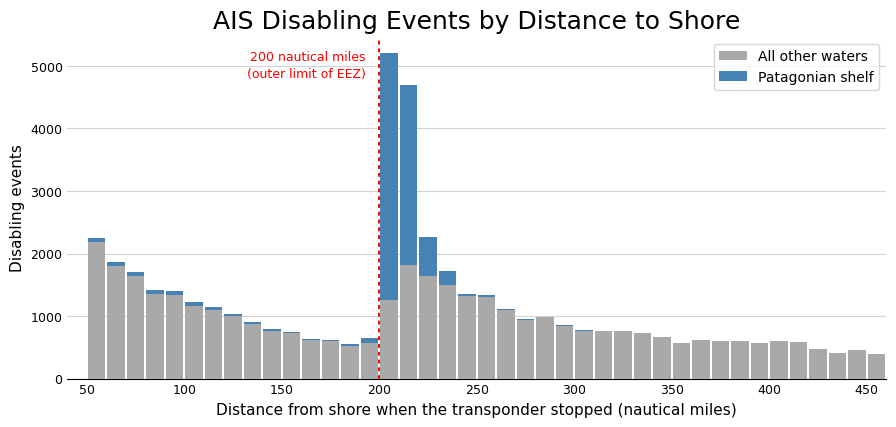

In [59]:
PATAGONIA = (-52, -38, -68, -52)      # lat_min, lat_max, lon_min, lon_max
PATAGONIA_ONLY = False
BIN_NM = 10
XMIN, XMAX = 40, 460                  # nautical miles
EEZ_NM = 200                          # the EEZ limit, by definition


nm = df["gap_start_distance_from_shore_m"] / 1852
in_pat = (df.gap_start_lat.between(PATAGONIA[0], PATAGONIA[1])
          & df.gap_start_lon.between(PATAGONIA[2], PATAGONIA[3]))

edges = np.arange(XMIN, XMAX + 1, BIN_NM)
centres = edges[:-1] + BIN_NM / 2
n_pat, _ = np.histogram(nm[in_pat], bins=edges)
n_oth, _ = np.histogram(nm[~in_pat], bins=edges)

fig, ax = plt.subplots(figsize=(9.2, 5.3))
fig.subplots_adjust(left=0.085, right=0.975, top=0.78, bottom=0.135)

if PATAGONIA_ONLY:
    ax.bar(centres, n_pat, width=BIN_NM*0.9, color='steelblue', zorder=3, label="Patagonian shelf")
else:
    ax.bar(centres, n_oth, width=BIN_NM*0.9, color='darkgrey', zorder=3, label="All other waters")
    ax.bar(centres, n_pat, width=BIN_NM*0.9, bottom=n_oth, color='steelblue', zorder=3,
           label="Patagonian shelf")

ax.axvline(EEZ_NM, color='red', linestyle=(0, (2, 2)), linewidth=1.4, zorder=5)
ax.text(EEZ_NM - 7, ax.get_ylim()[1] * 0.96,
        "200 nautical miles\n(outer limit of EEZ)",
        fontsize=9, color='red', va="top", ha="right", linespacing=1.4)

ax.set_xlim(XMIN, XMAX)
ax.set_xticks(np.arange(50, XMAX + 1, 50))
ax.set_xlabel("Distance from shore when the transponder stopped (nautical miles)",
              fontsize=11)
ax.set_ylabel("Disabling events", fontsize=11)


ax.grid(axis="y", linewidth=0.8, color='lightgrey', zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="both", length=0, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

h, l = ax.get_legend_handles_labels()
ax.legend()
          

outside = nm.between(EEZ_NM, EEZ_NM + 20)
outside_pat = outside & in_pat

ax.set_title("AIS Disabling Events by Distance to Shore", fontsize=18)


plt.show()

9,905 AIS disabling events begin in the 20 nautical miles just outside the EEZ.  69% of these events are on the Patagonian Shelf. Fragmented jurisdiction and limited enforcement capacity on the high seas make it easier for boats to turn off tracking and overfish without being caught. Vessels that are guilty of illegal fishing will often turn off AIS when approaching the outer limit of an EEZ. This allows foreign or otherwise unauthorized vessels to sneak in without permission. 

#### Figure 3: AIS disabling events align with the seasonality of fisheries 

The primary catch in the Patagonian Shelf region is Argentine shortfin squid. Argentine short-fin squid migrate into the Patagonian Shelf region from late January to late April and begin to migrate north/west in May and June (Falkland Islands Fisheries Department, 2026). By visualizing events on the Patagonian Shelf by month and gear type, a comparison to peak shortfin squid season may reveal deliberate transponder disabling. 

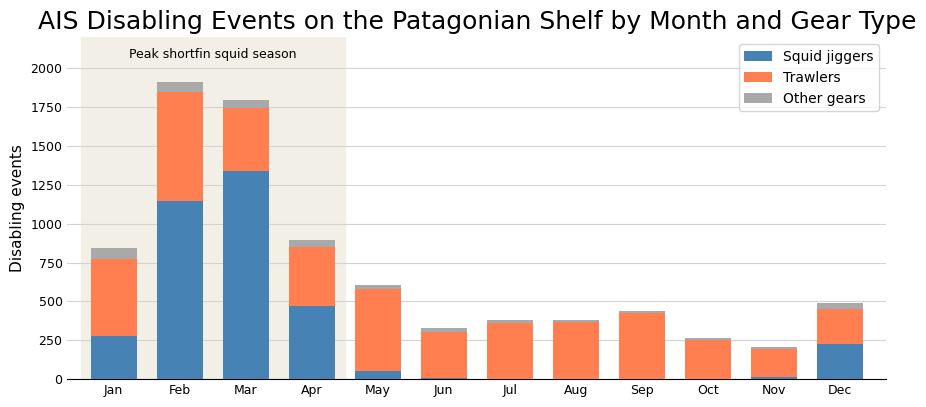

In [60]:
PATAGONIA = (-52, -38, -68, -52)      # lat_min, lat_max, lon_min, lon_max
SEASON = (-0.5, 3.5)                  # shaded months
YMAX = 2200


MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

in_pat = (df.gap_start_lat.between(PATAGONIA[0], PATAGONIA[1])
          & df.gap_start_lon.between(PATAGONIA[2], PATAGONIA[3]))
pat = df[in_pat].copy()
pat["month"] = pd.to_datetime(pat.gap_start_timestamp).dt.month

ct = pd.crosstab(pat.month, pat.vessel_class).reindex(range(1, 13), fill_value=0)
jig = ct.get("squid_jigger", pd.Series(0, index=ct.index)).to_numpy()
tra = ct.get("trawlers",     pd.Series(0, index=ct.index)).to_numpy()
oth = ct.drop(columns=[c for c in ("squid_jigger", "trawlers") if c in ct],
              errors="ignore").sum(axis=1).to_numpy()

x = np.arange(12)
fig, ax = plt.subplots(figsize=(9.2, 5.3))
fig.subplots_adjust(left=0.085, right=0.975, top=0.78, bottom=0.135)

ax.axvspan(*SEASON, color=SHADE, zorder=0)
ax.bar(x, jig, width=0.7, color='steelblue',   zorder=3, label="Squid jiggers")
ax.bar(x, tra, width=0.7, bottom=jig, color='coral', zorder=3, label="Trawlers")
ax.bar(x, oth, width=0.7, bottom=jig+tra, color='darkgrey', zorder=3, label="Other gears")

ax.text(np.mean(SEASON), YMAX * 0.97, "Peak shortfin squid season",
        ha="center", va="top", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(MONTHS)
ax.set_xlim(-0.7, 11.7)
ax.set_ylim(0, YMAX)
ax.set_ylabel("Disabling events", fontsize=11)


ax.grid(axis="y", color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)   # grid under the bars but still over the season shading
ax.tick_params(axis="both", length=0, labelsize=9)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)


ax.legend()

ax.set_title("AIS Disabling Events on the Patagonian Shelf by Month and Gear Type", fontsize=18)

plt.show()

Squid jiggers are present in mass only during squid season (Jan - Apr) and then dissapear during the winter. However, trawlers that are fishing the same waters in the same months, under the same satellites, show no comparable seasonality in AIS outages. If thin satellite coverage or bad weather over the South Atlantic were darkening transponders, it would darken trawlers and jiggers alike. Instead, the squid jigger fleet's disabling follows its target species' calendar, which points to suspiscious behavior rather than failing infrastructure.

#### Summary 

A large number of AIS disabling events are not happening at random. From examining this dataset, it is apparent that AIS disabling events align with EEZ boundaries and fishing seasons in a way that equipment failure can not explain. One fishery in the Patagonian Shelf region accounts for a striking share of disabling events happening within the 20 nautical miles outside of the EEZ. AIS disabling event patterns in the Patagonia Shelf region are consistent with deliberate concealment during the most productive months of a high-value fishery.

This analysis does not show that any particular vessel fished illegally. Legitimate reasons to disable AIS exist, and disabling is not itself unlawful in most contexts. Instead, these patterns and observations can be used to improve monitoring and enforcement and make recommendations for the allocation of surveillance resources. Surveillance should be prioritized along EEZ boundaries and within regions that are identified as AIS outage 'hot spots'. Repeat AIS outage offenders in zones of high priority should also be further investigated. Additionally, these findings can be used to advocate for nationwide AIS requirements and the importance of monitoring vessel behavior at sea. 

#### References

Falkland Islands Fisheries Department. (2026). Argentine shortfin squid (Illex). Falkland Islands Government. 

Global Fishing Watch. (2026, June). Illegal fishing thrives out of sight. Transparency brings it into view. https://globalfishingwatch.org/statement/illegal-fishing-thrives-out-of-sight-transparency-brings-it-into-view/


National Oceanic and Atmospheric Administration. (2022, November 2). Learning more about “dark” fishing vessels' activities at sea. NOAA Fisheries. https://www.fisheries.noaa.gov/feature-story/learning-more-about-dark-fishing-vessels-activities-sea

Seafood Watch. (n.d.). Argentine shortfin squid. Monterey Bay Aquarium. https://www.seafoodwatch.org/recommendation/squid/argentine-shortfin-squid-33493

Urbina, I. (Host). (2023, January). Slavery At Sea (No. 3) [Audio podcast episode]. In The Outlaw Ocean. CBC Podcasts / The Outlaw Ocean Project. https://theoutlawocean.com/podcast/slavery-at-sea

Welch, H., Clavelle, T., White, T. D., Cimino, M. A., Van Osdel, J., Hochberg, T., Kroodsma, D., & Hazen, E. L. (2022). Hot spots of unseen fishing vessels. Science Advances, 8(44), eabq2109. https://doi.org/10.1126/sciadv.abq2109

Woodill, A. J., Kavanaugh, M., Harte, M., & Watson, J. R. (2020). Predicting illegal fishing on the Patagonia Shelf from oceanographic seascapes. arXiv. https://doi.org/10.48550/arXiv.2007.05470